# 16. Communicating Explanations to Stakeholders

The previous notebook treated explanations as governance artifacts. This notebook focuses on the final mile:

> How do we communicate model explanations so different stakeholders can make defensible decisions?

A technical explanation is not the same thing as a useful explanation. An executive wants decision risk and business tradeoffs. A model validator wants reproducibility and limitations. A frontline analyst wants case-specific reasoning and escalation rules. An affected stakeholder needs a clear, honest, non-misleading explanation of the decision and feasible next steps.

This notebook turns explanation outputs into stakeholder-ready communication products.

## Learning Objectives

By the end of this notebook, you should be able to:

1. Match explanation depth to stakeholder needs.
2. Separate model behavior, statistical association, causal claims, and action advice.
3. Build stakeholder-specific explanation packets from the same technical evidence.
4. Communicate score uncertainty and threshold sensitivity without overwhelming the reader.
5. Write explanation language that is accurate, concise, auditable, and appropriately caveated.
6. Create a reusable communication checklist for model-supported decisions.

## 1. The Communication Problem

Miller (2019) emphasizes that explanations are social: people ask for explanations in context, often contrastively, and they prefer explanations that are selective rather than exhaustive. Lipton (2018) argues that interpretability is often underspecified; different users may mean transparency, trust, debugging, causality, fairness, or control. Model cards similarly encourage explicit reporting of intended use, performance, limitations, and ethical considerations (Mitchell et al., 2019).

For a decision-science workflow, this means one explanation should usually become several communication layers:

| Stakeholder | Main question | What they need |
|---|---|---|
| Executive sponsor | Should we deploy or revise the decision system? | Business impact, risk, fairness, monitoring plan |
| Model validator | Is the evidence reproducible and fit for purpose? | Data, model version, metrics, limitations, stability |
| Frontline analyst | How should I use the score for a specific case? | Case reasons, threshold distance, escalation rules |
| Affected stakeholder | Why did this decision happen and what can be done? | Plain-language reasons, non-misleading caveats, feasible next steps |
| Auditor or regulator | Can the decision be reviewed later? | Traceability, policy basis, documentation, logs |

## 2. A Communication Ladder

A useful explanation packet should climb a ladder from technical evidence to decision language.

| Layer | Question | Example output |
|---|---|---|
| Prediction | What did the model estimate? | Predicted repayment probability is 0.41. |
| Decision policy | How was the score used? | Approval threshold is 0.52. |
| Main drivers | What features moved the score? | Cash buffer and revenue lowered the score. |
| Uncertainty | How stable is the conclusion? | Score is close to the threshold, so manual review is recommended. |
| Limitation | What should not be inferred? | This is not a causal claim about why the business will fail. |
| Action path | What can be done next? | Request updated financials or route to secondary review. |

The mistake is to stop at a feature-importance chart. Communication requires translating the chart into the decision context.

In [1]:
# Section focus: 2. A Communication Ladder.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

import os
os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib-cache')

import json
import textwrap
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_SEED = 816
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 130
pd.set_option('display.max_colwidth', 160)


def sigmoid(z):
    """Map a linear score to a probability-like value for the notebook simulation.
    
    Parameters
    ----------
    z : object
        Linear predictor or standardized score being transformed by this helper.
    
    Returns
    -------
    object
        Numeric diagnostic, score, or transformed value from the sigmoid calculation.
    """
    return 1 / (1 + np.exp(-z))

In [2]:
# Section focus: 2. A Communication Ladder.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def display_table(df, precision=3, max_width='880px'):
    """Display table for the 16. Communicating Explanations to Stakeholders notebook output.
    
    Parameters
    ----------
    df : object
        Input data frame containing the rows used in this notebook example.
    precision : object
        Number of decimal places used when formatting numeric output.
    max_width : object
        Maximum display width used to keep rendered tables readable.
    
    Returns
    -------
    object
        None. The function updates a plot, display object, or notebook state as its side effect.
    """
    styler = df.style.format(precision=precision)
    styler = styler.set_table_styles([
        {'selector': 'th', 'props': [('white-space', 'normal'), ('text-align', 'left'), ('vertical-align', 'top')]},
        {'selector': 'td', 'props': [('white-space', 'normal'), ('text-align', 'left'), ('vertical-align', 'top'), ('line-height', '1.3')]},
        {'selector': 'table', 'props': [('table-layout', 'fixed'), ('width', max_width)]},
    ])
    display(styler)


def wrap_text(text, width=92):
    """Carry out the wrap text step used in the 16. Communicating Explanations to Stakeholders workflow.
    
    Parameters
    ----------
    text : object
        Text produced or inspected by the language-model workflow.
    width : object
        Display setting used to make the plot or table readable in the rendered notebook.
    
    Returns
    -------
    object
        Numeric diagnostic, score, or transformed value from the wrap text calculation.
    """
    return '\n'.join(textwrap.wrap(str(text), width=width))

For A Communication Ladder, the right question is whether this explanation can survive baseline, sample, or neighborhood changes.


## 3. Working Example: Working-Capital Approval

We reuse the broad setting from the previous notebook. A model predicts whether a small business will repay a working-capital product. The decision rule approves applications whose predicted repayment score exceeds a threshold.

The communication task includes displaying the score and explaining how it should be used. We need to explain what the score means, how the decision rule used it, which features contributed to the decision, how close the case is to the threshold, and which caveats matter for the intended audience.

In [3]:
# Section focus: 3. Working Example: Working-Capital Approval.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def make_working_capital_data(n=7200, seed=RANDOM_SEED):
    """Construct the working capital data helper used in the 16. Communicating Explanations to Stakeholders workflow.
    
    Parameters
    ----------
    n : object
        Number of observations or simulation units used by the calculation.
    seed : object
        Random seed used to make the simulation reproducible.
    
    Returns
    -------
    object
        pandas.DataFrame containing the tabular result produced by this function.
    """
    rng = np.random.default_rng(seed)

    underserved_access_group = rng.binomial(1, 0.34, n)
    sector_volatility = rng.normal(0.15 * underserved_access_group, 1, n)
    business_age = rng.normal(-0.22 * underserved_access_group, 1, n)
    operating_strength = rng.normal(-0.12 * underserved_access_group, 1, n)

    revenue = (
        0.72 * operating_strength
        + 0.34 * business_age
        - 0.28 * sector_volatility
        - 0.30 * underserved_access_group
        + rng.normal(0, 0.78, n)
    )
    cash_buffer = (
        0.68 * operating_strength
        - 0.28 * sector_volatility
        - 0.20 * underserved_access_group
        + rng.normal(0, 0.78, n)
    )
    credit_history = (
        0.62 * operating_strength
        + 0.22 * business_age
        - 0.52 * underserved_access_group
        + rng.normal(0, 0.88, n)
    )
    digital_records = (
        0.50 * operating_strength
        + 0.20 * business_age
        - 0.44 * underserved_access_group
        + rng.normal(0, 0.88, n)
    )
    collateral = 0.42 * revenue + 0.26 * business_age - 0.45 * underserved_access_group + rng.normal(0, 0.92, n)
    relationship_length = 0.52 * business_age + 0.14 * operating_strength - 0.18 * underserved_access_group + rng.normal(0, 0.82, n)

    repayment_logit = (
        -0.08
        + 0.80 * operating_strength
        + 0.42 * cash_buffer
        + 0.34 * revenue
        + 0.24 * relationship_length
        - 0.48 * sector_volatility
        + 0.15 * digital_records
    )
    repay_probability = sigmoid(repayment_logit)
    repays = rng.binomial(1, repay_probability)

    df = pd.DataFrame({
        'underserved_access_group': underserved_access_group,
        'sector_volatility': sector_volatility,
        'business_age': business_age,
        'operating_strength_latent': operating_strength,
        'revenue': revenue,
        'cash_buffer': cash_buffer,
        'credit_history': credit_history,
        'digital_records': digital_records,
        'collateral': collateral,
        'relationship_length': relationship_length,
        'repays': repays,
        'repay_probability_true': repay_probability,
    })
    df['access_group'] = np.where(df['underserved_access_group'] == 1, 'Underserved access group', 'Established access group')
    return df

applications = make_working_capital_data()
applications.head()

,underserved_access_group,sector_volatility,business_age,operating_strength_latent,revenue,cash_buffer,credit_history,digital_records,collateral,relationship_length,repays,repay_probability_true,access_group
0,1,0.162338,-1.337732,-2.072640,-2.886814,-1.048302,-2.752118,-1.238309,-1.530938,-1.315438,0,0.023219,Underserved access group
1,0,-0.507972,-1.688313,0.567266,-0.067704,1.170602,0.093350,-0.529185,-0.072741,-0.635109,1,0.701504,Established access group
2,0,0.974099,-0.736577,-0.880031,-0.791438,-0.428240,-0.824057,-0.230213,0.729380,-1.523029,0,0.109038,Established access group
3,0,0.920325,-2.705400,-2.225799,-1.264086,-1.523380,-1.449664,-2.426805,-1.186763,-2.243089,0,0.013730,Established access group
4,0,0.702408,-0.824385,2.490206,1.831298,2.232007,1.501651,0.536880,0.996055,-1.612576,1,0.944202,Established access group


Use the explanation as a stress test of the model narrative. In Working Example: Working-Capital Approval, the displayed reasons should make sense with the data-generating story and the operating decision. A report is stronger when it is honest about disagreement across explanation views.


In [4]:
# Section focus: 3. Working Example: Working-Capital Approval.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

model_features = [
    'revenue',
    'cash_buffer',
    'credit_history',
    'digital_records',
    'collateral',
    'relationship_length',
    'sector_volatility',
    'business_age',
]

train_df, test_df = train_test_split(
    applications,
    test_size=0.35,
    random_state=RANDOM_SEED,
    stratify=applications['repays'],
)

model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))
model.fit(train_df[model_features], train_df['repays'])

test_df = test_df.copy()
test_df['score'] = model.predict_proba(test_df[model_features])[:, 1]
threshold = test_df['score'].quantile(0.58)
test_df['approved'] = (test_df['score'] >= threshold).astype(int)
test_df['decision'] = np.where(test_df['approved'] == 1, 'Approve', 'Deny or route to review')

model_metrics = pd.DataFrame({
    'metric': ['ROC AUC', 'Average precision', 'Brier score', 'Approval rate', 'Repayment rate', 'Decision threshold'],
    'value': [
        roc_auc_score(test_df['repays'], test_df['score']),
        average_precision_score(test_df['repays'], test_df['score']),
        brier_score_loss(test_df['repays'], test_df['score']),
        test_df['approved'].mean(),
        test_df['repays'].mean(),
        threshold,
    ],
})

display_table(model_metrics, precision=3, max_width='620px')

,metric,value
0,ROC AUC,0.819
1,Average precision,0.794
2,Brier score,0.172
3,Approval rate,0.420
4,Repayment rate,0.448
5,Decision threshold,0.500


The model has enough signal to be useful, but the communication problem remains. A stakeholder does not need every coefficient. They need the subset of evidence relevant to their decision rights.

This result is an interpretation diagnostic. For Working Example: Working-Capital Approval, look at whether the explanation is stable, plausible, and useful for stakeholder review. The analyst should report this as sensitivity in the explanation layer.


## 4. A Stakeholder Communication Map

The same technical evidence can be packaged differently without changing the underlying facts. The map below shows the translation pipeline.

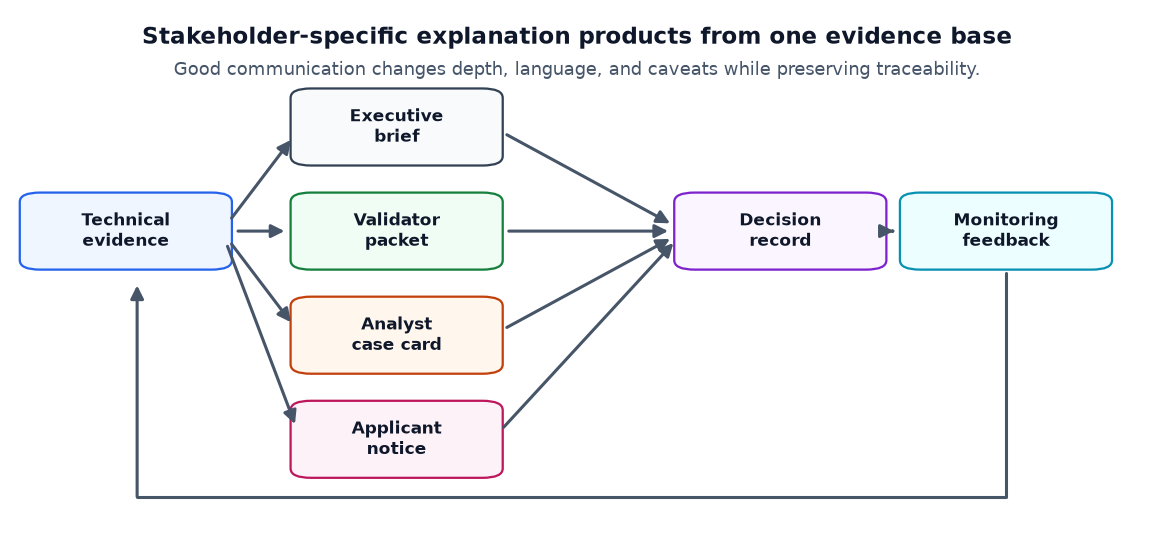

In [5]:
# Section focus: 4. A Stakeholder Communication Map.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def draw_communication_map():
    """Carry out the draw communication map step used in the 16. Communicating Explanations to Stakeholders workflow.
    
    Parameters
    ----------
    None
        This helper uses values defined in the surrounding notebook cell.
    
    Returns
    -------
    object
        Tuple of outputs from this workflow, usually data, fitted objects, or diagnostics used by later cells.
    """
    fig, ax = plt.subplots(figsize=(11.2, 5.2))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')

    boxes = [
        ('Technical\nevidence', 0.10, 0.58, '#eff6ff', '#2563eb'),
        ('Executive\nbrief', 0.34, 0.78, '#f8fafc', '#334155'),
        ('Validator\npacket', 0.34, 0.58, '#f0fdf4', '#15803d'),
        ('Analyst\ncase card', 0.34, 0.38, '#fff7ed', '#c2410c'),
        ('Applicant\nnotice', 0.34, 0.18, '#fdf2f8', '#be185d'),
        ('Decision\nrecord', 0.68, 0.58, '#faf5ff', '#7e22ce'),
        ('Monitoring\nfeedback', 0.88, 0.58, '#ecfeff', '#0891b2'),
    ]

    positions = {}
    def add_box(label, x, y, face, edge):
        """Carry out the add box step used in the 16. Communicating Explanations to Stakeholders workflow.
        
        Parameters
        ----------
        label : object
            Human-readable label used to name a model, scenario, metric, or plotted series.
        x : object
            Numeric score, scalar, or array passed through the transformation in this helper.
        y : object
            Observed target values used for fitting or evaluation.
        face : object
            Face color used to encode a node or region in a graph or plot.
        edge : object
            Graph edge being drawn, classified, or checked for consistency.
        
        Returns
        -------
        object
            None. The function updates a plot, display object, or notebook state as its side effect.
        """
        positions[label] = (x, y)
        patch = FancyBboxPatch(
            (x - 0.082, y - 0.062), 0.164, 0.124,
            boxstyle='round,pad=0.012,rounding_size=0.018',
            facecolor=face, edgecolor=edge, linewidth=1.25,
        )
        ax.add_patch(patch)
        ax.text(x, y, label, ha='center', va='center', fontsize=9.4, weight='bold', color='#0f172a')

    def arrow(start, end, rad=0.0):
        """Carry out the arrow step used in the 16. Communicating Explanations to Stakeholders workflow.
        
        Parameters
        ----------
        start : object
            Starting index, time, or location for the simulated event window.
        end : object
            Ending index, time, or location for the simulated event window.
        rad : object
            Curvature setting used to route a graph edge around other visual elements.
        
        Returns
        -------
        object
            None. The function updates a plot, display object, or notebook state as its side effect.
        """
        ax.add_patch(FancyArrowPatch(
            start, end,
            connectionstyle=f'arc3,rad={rad}',
            arrowstyle='-|>', mutation_scale=15,
            linewidth=1.7, color='#475569', shrinkA=9, shrinkB=9,
        ))

    for item in boxes:
        add_box(*item)

    evidence = (0.185, 0.58)
    for end in [(0.255, 0.78), (0.255, 0.58), (0.255, 0.38), (0.255, 0.18)]:
        arrow(evidence, end)
    for start in [(0.425, 0.78), (0.425, 0.58), (0.425, 0.38), (0.425, 0.18)]:
        arrow(start, (0.595, 0.58))
    arrow((0.765, 0.58), (0.795, 0.58))

    # Route feedback around the bottom so it reads as a loop without crossing stakeholder cards.
    feedback_color = '#475569'
    ax.plot([0.88, 0.88, 0.11], [0.50, 0.07, 0.07], color=feedback_color, linewidth=1.7)
    ax.add_patch(FancyArrowPatch(
        (0.11, 0.07), (0.11, 0.50),
        arrowstyle='-|>', mutation_scale=15,
        linewidth=1.7, color=feedback_color,
        shrinkA=0, shrinkB=7,
    ))

    ax.text(0.50, 0.94, 'Stakeholder-specific explanation products from one evidence base', ha='center', fontsize=13, weight='bold', color='#0f172a')
    ax.text(0.50, 0.88, 'Good communication changes depth, language, and caveats while preserving traceability.', ha='center', fontsize=10.2, color='#475569')
    return fig, ax

draw_communication_map();
plt.show()

The map makes two ideas explicit. First, stakeholder summaries should come from the same evidence base. Second, every communication product should feed into a decision record so that the organization can later reconstruct what was said and why.

The explanation result should be compared with the decision story. In A Stakeholder Communication Map, stable features, changing local reasons, and disagreement across explainers tell us how much trust to place in the model narrative. Good explanations reduce ambiguity for stakeholders. Weak ones push the burden back onto human reviewers.


## 5. Score, Threshold, and Calibration Language

Most stakeholders do not need raw logits. They need the score in relation to a policy threshold and the reliability of the score.

The model score is:

$$
S_i = \widehat P(Y_i = 1 \mid X_i).
$$

The decision rule is:

$$
D_i = \mathbf{1}\{S_i \ge \tau\},
$$

where $\tau$ is the approval threshold. A communication packet should state both $S_i$ and $\tau$ when explaining a case-level decision.

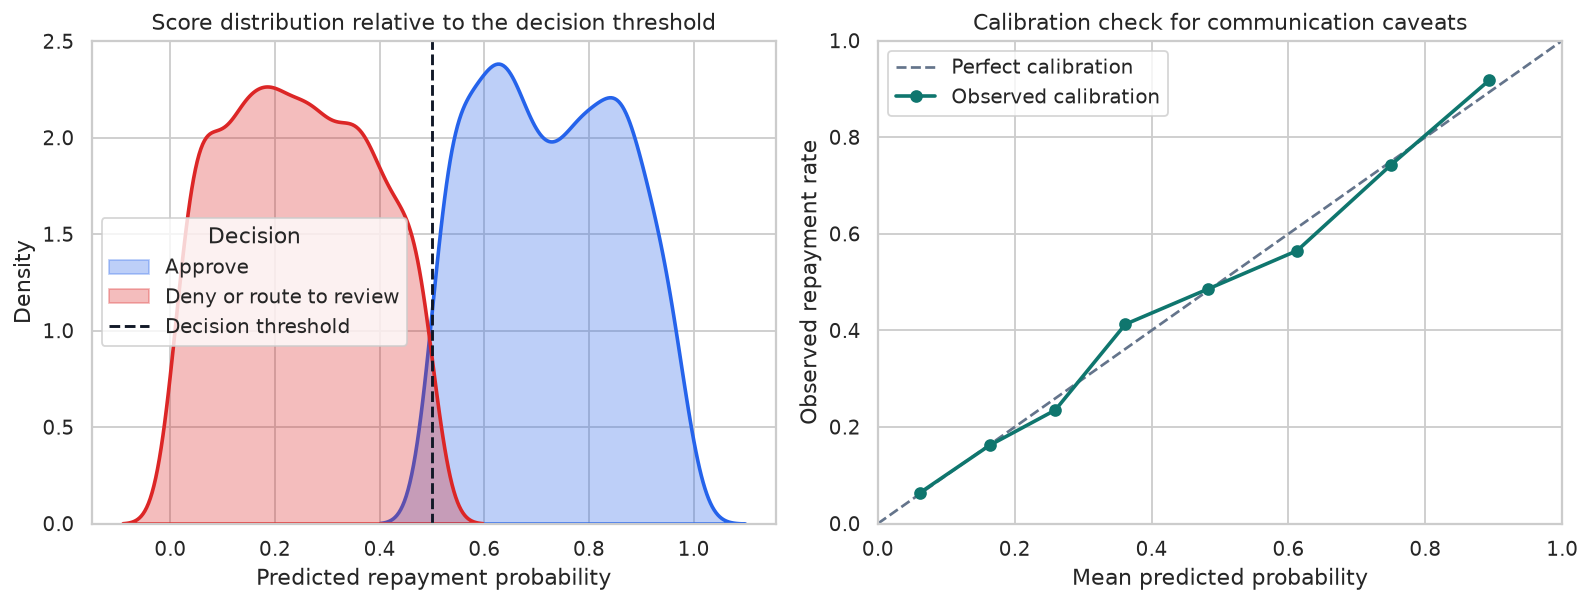

In [6]:
# Section focus: 5. Score, Threshold, and Calibration Language.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

from matplotlib.lines import Line2D
from matplotlib.patches import Patch

fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.8))

score_colors = {'Approve': '#2563eb', 'Deny or route to review': '#dc2626'}
for decision_label, color in score_colors.items():
    sns.kdeplot(
        data=test_df.loc[test_df['decision'] == decision_label],
        x='score',
        common_norm=False,
        fill=True,
        alpha=0.30,
        linewidth=2,
        color=color,
        ax=axes[0],
    )
axes[0].axvline(threshold, color='#111827', linestyle='--', linewidth=1.6)
axes[0].set_title('Score distribution relative to the decision threshold')
axes[0].set_xlabel('Predicted repayment probability')
axes[0].set_ylabel('Density')
axes[0].legend(
    handles=[
        Patch(facecolor=score_colors['Approve'], edgecolor=score_colors['Approve'], alpha=0.30, label='Approve'),
        Patch(facecolor=score_colors['Deny or route to review'], edgecolor=score_colors['Deny or route to review'], alpha=0.30, label='Deny or route to review'),
        Line2D([0], [0], color='#111827', linestyle='--', linewidth=1.6, label='Decision threshold'),
    ],
    title='Decision',
)

prob_true, prob_pred = calibration_curve(test_df['repays'], test_df['score'], n_bins=8, strategy='quantile')
axes[1].plot([0, 1], [0, 1], color='#64748b', linestyle='--', label='Perfect calibration')
axes[1].plot(prob_pred, prob_true, marker='o', color='#0f766e', linewidth=2, label='Observed calibration')
axes[1].set_title('Calibration check for communication caveats')
axes[1].set_xlabel('Mean predicted probability')
axes[1].set_ylabel('Observed repayment rate')
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)
axes[1].legend()

plt.tight_layout()
plt.show()

A calibrated probability is easier to communicate than an arbitrary score. When calibration is imperfect, explain the score as a ranking or risk indicator rather than as a precise probability. This distinction matters when a score is close to the threshold.

Use the explanation as a stress test of the model narrative. In Score, Threshold, and Calibration Language, the displayed reasons should make sense with the data-generating story and the operating decision. The analyst should compare the methods before turning the local story into a recommendation.


## 6. Communicating Uncertainty With Bootstrap Intervals

A stakeholder-facing metric should not look more precise than it is. We will use a simple bootstrap to place intervals around three communication metrics: ROC AUC, approval rate, and repayment rate among approved applicants.

In [7]:
# Section focus: 6. Communicating Uncertainty With Bootstrap Intervals.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def bootstrap_metric_intervals(df, n_boot=300, seed=RANDOM_SEED):
    """Carry out the bootstrap metric intervals step used in the 16. Communicating Explanations to Stakeholders workflow.
    
    Parameters
    ----------
    df : object
        Input data frame containing the rows used in this notebook example.
    n_boot : object
        Count or size setting for the bootstrap metric intervals calculation.
    seed : object
        Random seed used to make the simulation reproducible.
    
    Returns
    -------
    object
        pandas.DataFrame containing the tabular result produced by this function.
    """
    rng = np.random.default_rng(seed)
    rows = []
    n = len(df)
    for _ in range(n_boot):
        sample_idx = rng.integers(0, n, n)
        sample = df.iloc[sample_idx]
        if sample['repays'].nunique() < 2:
            continue
        approved = sample.loc[sample['approved'] == 1]
        rows.append({
            'ROC AUC': roc_auc_score(sample['repays'], sample['score']),
            'Approval rate': sample['approved'].mean(),
            'Repayment rate among approved': approved['repays'].mean(),
        })
    draws = pd.DataFrame(rows)
    summary = []
    for metric in draws.columns:
        summary.append({
            'metric': metric,
            'estimate': {
                'ROC AUC': roc_auc_score(df['repays'], df['score']),
                'Approval rate': df['approved'].mean(),
                'Repayment rate among approved': df.loc[df['approved'] == 1, 'repays'].mean(),
            }[metric],
            'ci_low': draws[metric].quantile(0.025),
            'ci_high': draws[metric].quantile(0.975),
        })
    return pd.DataFrame(summary)

uncertainty_table = bootstrap_metric_intervals(test_df)
display_table(uncertainty_table, precision=3, max_width='700px')

,metric,estimate,ci_low,ci_high
0,ROC AUC,0.819,0.802,0.835
1,Approval rate,0.420,0.400,0.441
2,Repayment rate among approved,0.714,0.685,0.740


The explanation result should be compared with the decision story. In Communicating Uncertainty With Bootstrap Intervals, stable features, changing local reasons, and disagreement across explainers tell us how much trust to place in the model narrative. In practice, a clearer explanation lowers review burden and makes the recommendation easier to defend.


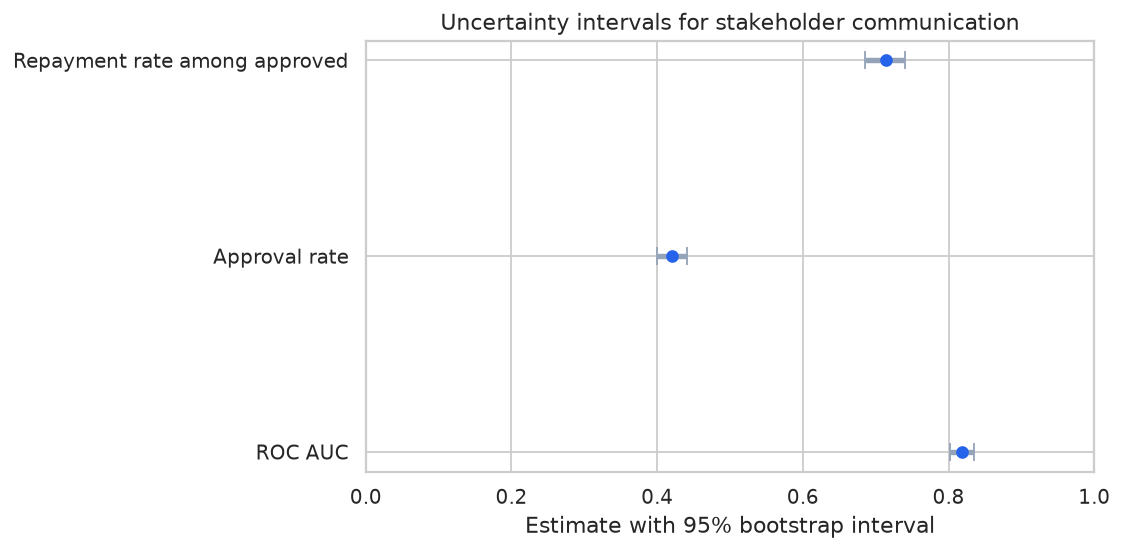

In [8]:
fig, ax = plt.subplots(figsize=(8.8, 4.4))
plot_df = uncertainty_table.copy()
y = np.arange(len(plot_df))
ax.errorbar(
    plot_df['estimate'], y,
    xerr=[plot_df['estimate'] - plot_df['ci_low'], plot_df['ci_high'] - plot_df['estimate']],
    fmt='o', color='#2563eb', ecolor='#94a3b8', elinewidth=3, capsize=5,
)
ax.set_yticks(y)
ax.set_yticklabels(plot_df['metric'])
ax.set_xlabel('Estimate with 95% bootstrap interval')
ax.set_title('Uncertainty intervals for stakeholder communication')
ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()

Intervals support better communication because they make uncertainty visible. The executive version might say, "In evaluation data, the model approved about 42% of applications; among approved applications, the observed repayment rate was around the interval shown above." The validator version should include the exact bootstrap procedure.

## 7. Local Explanation for a Single Case

We now build a case-level explanation. For the standardized logistic model:

$$
\operatorname{logit}(S_i) = \beta_0 + \sum_j \beta_j z_{ij}.
$$

The local contribution of feature $j$ is:

$$
\phi_{ij} = \beta_j z_{ij}.
$$

Positive contributions raise the approval score; negative contributions lower it. This explanation is faithful to this model, but it is still not causal. It tells us how the score was computed, not what caused repayment risk.

The selected case should be read as a stakeholder communication exercise rather than a coefficient exercise. The applicant sits near a decision boundary, so small changes in documentation or review policy could matter. That is exactly where explanation language needs to be precise.

The experiment asks whether we can translate model mechanics into a useful case note without overstating causality or promising guaranteed approval. A faithful local explanation describes how the current model scored the case. It should also say which fields are actionable, which are historical context, and which require human judgment.


In [9]:
# Section focus: 7. Local Explanation for a Single Case.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

scaler = model.named_steps['standardscaler']
logit_model = model.named_steps['logisticregression']
coefs = pd.Series(logit_model.coef_[0], index=model_features)
standardized = (test_df[model_features] - scaler.mean_) / scaler.scale_
contributions = standardized * coefs
logit_scores = logit_model.intercept_[0] + contributions.sum(axis=1)
logit_threshold = np.log(threshold / (1 - threshold))

test_df['logit_score'] = logit_scores
# Choose a denied case close enough to the threshold to make communication nuanced.
candidates = test_df.loc[test_df['approved'] == 0].copy()
candidates['threshold_distance'] = logit_threshold - candidates['logit_score']
focal_id = candidates.loc[candidates['threshold_distance'].between(0.15, 0.75), 'threshold_distance'].sort_values().index[8]
focal = test_df.loc[focal_id]
focal_contrib = contributions.loc[focal_id].sort_values()

case_summary = pd.DataFrame({
    'quantity': [
        'Decision',
        'Predicted repayment score',
        'Approval threshold',
        'Score gap to threshold',
        'Observed outcome in evaluation data',
        'Audit group',
    ],
    'value': [
        focal['decision'],
        focal['score'],
        threshold,
        threshold - focal['score'],
        'Repaid' if focal['repays'] == 1 else 'Did not repay',
        focal['access_group'],
    ],
})

display_table(case_summary, precision=3, max_width='680px')

,quantity,value
0,Decision,Deny or route to review
1,Predicted repayment score,0.461
2,Approval threshold,0.500
3,Score gap to threshold,0.040
4,Observed outcome in evaluation data,Repaid
5,Audit group,Established access group


Read Local Explanation for a Single Case as a communication test. A reportable explanation should be clear, checkable, and reasonably stable.


In [10]:
local_table = pd.DataFrame({
    'feature': focal_contrib.index,
    'local_logit_contribution': focal_contrib.values,
    'direction': np.where(focal_contrib.values >= 0, 'Raised score', 'Lowered score'),
})
local_table['abs_contribution'] = local_table['local_logit_contribution'].abs()
local_table = local_table.sort_values('abs_contribution', ascending=False)
display_table(local_table.drop(columns='abs_contribution'), precision=3, max_width='760px')

,feature,local_logit_contribution,direction
7,cash_buffer,0.604,Raised score
0,relationship_length,-0.314,Lowered score
1,credit_history,-0.257,Lowered score
6,revenue,0.202,Raised score
2,digital_records,-0.118,Lowered score
3,sector_volatility,-0.115,Lowered score
5,business_age,0.111,Raised score
4,collateral,0.038,Raised score


Use Local Explanation for a Single Case to test whether the explanation story is credible. The displayed reasons should line up with the data-generating story and the operating decision, and unstable attributions should be called out clearly.


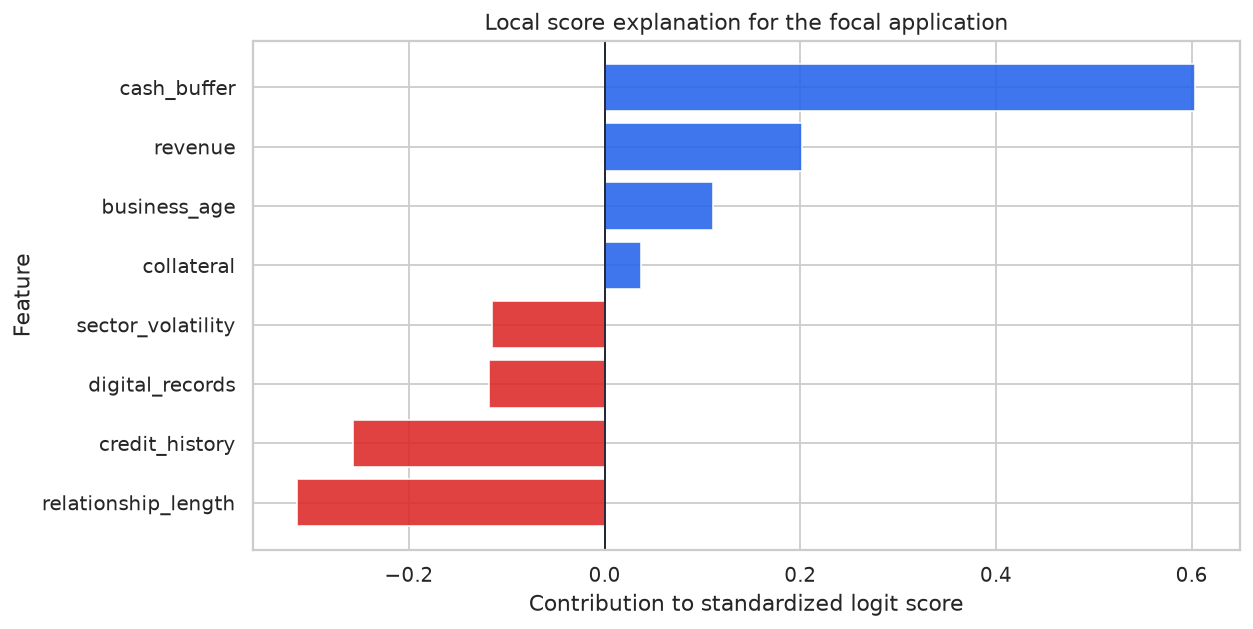

In [11]:
plot_local = focal_contrib.sort_values()
fig, ax = plt.subplots(figsize=(9.8, 5.0))
colors = ['#dc2626' if value < 0 else '#2563eb' for value in plot_local.values]
ax.barh(plot_local.index, plot_local.values, color=colors, alpha=0.88)
ax.axvline(0, color='#111827', linewidth=1)
ax.set_title('Local score explanation for the focal application')
ax.set_xlabel('Contribution to standardized logit score')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.show()

The local explanation is a technical object. The next step is to translate it into stakeholder-specific language. Notice that the same result should be worded differently for an analyst, an applicant, and a model validator.

Local Explanation for a Single Case should make the model story easier to inspect instead of merely more polished.


## 8. Four Stakeholder-Specific Explanation Packets

We will create four explanation packets from the same evidence:

1. Executive brief.
2. Model validator packet.
3. Frontline analyst case card.
4. Applicant-facing notice.

The goal is not to hide complexity. The goal is to route the right complexity to the right audience.

In [12]:
# Section focus: 8. Four Stakeholder-Specific Explanation Packets.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def top_reasons(local_contrib, n=3, direction='negative'):
    """Carry out the top reasons step used in the 16. Communicating Explanations to Stakeholders workflow.
    
    Parameters
    ----------
    local_contrib : object
        The local contrib setting that controls the top reasons calculation in this notebook.
    n : object
        Number of observations or simulation units used by the calculation.
    direction : object
        The direction setting that controls the top reasons calculation in this notebook.
    
    Returns
    -------
    object
        Intermediate result produced by the top reasons calculation and reused by later cells.
    """
    if direction == 'negative':
        selected = local_contrib.sort_values().head(n)
    elif direction == 'positive':
        selected = local_contrib.sort_values(ascending=False).head(n)
    else:
        selected = local_contrib.abs().sort_values(ascending=False).head(n)
        selected = local_contrib.loc[selected.index]
    return [f'{feature} ({value:+.2f})' for feature, value in selected.items()]

negative_reasons = top_reasons(focal_contrib, n=3, direction='negative')
positive_reasons = top_reasons(focal_contrib, n=2, direction='positive')

communication_packets = pd.DataFrame({
    'stakeholder': [
        'Executive sponsor',
        'Model validator',
        'Frontline analyst',
        'Applicant-facing notice',
    ],
    'message': [
        f"The approval model separates repayment risk well in evaluation data (ROC AUC {model_metrics.loc[model_metrics['metric']=='ROC AUC','value'].iloc[0]:.2f}). Deployment should include threshold monitoring, subgroup reporting, and manual review for near-threshold cases.",
        f"Model version uses standardized logistic regression with {len(model_features)} input features. Threshold is {threshold:.3f}; local explanations are standardized logit contributions. Validate calibration, subgroup metrics, and threshold sensitivity before release.",
        f"This case is below the approval threshold. Main score-lowering signals: {', '.join(negative_reasons)}. Main score-raising signals: {', '.join(positive_reasons)}. Because the case is near threshold, request updated documentation or route to secondary review.",
        "The application did not meet the current automated approval threshold. The main review areas are relationship history, credit-history information, and completeness of digital records. This explanation describes the model's scoring factors and does not claim these factors caused future repayment behavior.",
    ],
    'must_include': [
        'Business decision, deployment conditions, monitoring responsibilities.',
        'Data/model version, feature list, threshold, method limitations.',
        'Case score, threshold gap, top reasons, escalation rule.',
        'Plain language, non-causal wording, feasible next steps, appeal/review path.',
    ],
})

display_table(communication_packets, precision=3, max_width='980px')

,stakeholder,message,must_include
0,Executive sponsor,"The approval model separates repayment risk well in evaluation data (ROC AUC 0.82). Deployment should include threshold monitoring, subgroup reporting, and manual review for near-threshold cases.","Business decision, deployment conditions, monitoring responsibilities."
1,Model validator,"Model version uses standardized logistic regression with 8 input features. Threshold is 0.500; local explanations are standardized logit contributions. Validate calibration, subgroup metrics, and threshold sensitivity before release.","Data/model version, feature list, threshold, method limitations."
2,Frontline analyst,"This case is below the approval threshold. Main score-lowering signals: relationship_length (-0.31), credit_history (-0.26), digital_records (-0.12). Main score-raising signals: cash_buffer (+0.60), revenue (+0.20). Because the case is near threshold, request updated documentation or route to secondary review.","Case score, threshold gap, top reasons, escalation rule."
3,Applicant-facing notice,"The application did not meet the current automated approval threshold. The main review areas are relationship history, credit-history information, and completeness of digital records. This explanation describes the model's scoring factors and does not claim these factors caused future repayment behavior.","Plain language, non-causal wording, feasible next steps, appeal/review path."


The applicant-facing notice is intentionally different from the analyst card. It avoids raw coefficients and avoids implying that the model has discovered causes. It also avoids saying, "increase this exact feature by 0.37 standard deviations," because that is not meaningful or necessarily feasible for the applicant.

## 9. Bad Explanation Versus Better Explanation

The easiest way to overclaim is to use causal language for a predictive score. The table below contrasts risky language with safer language.

| Risky phrasing | Why it is risky | Better phrasing |
|---|---|---|
| "The loan was denied because revenue caused high risk." | Treats a model contribution as a causal claim. | "Revenue was one factor that lowered the model score." |
| "The model is fair because we did not use group membership." | Ignores proxies and subgroup performance. | "Group membership was excluded from fitting; subgroup metrics are monitored separately." |
| "The model predicts repayment with 83% certainty." | Confuses AUC with individual probability or certainty. | "The model's ROC AUC is 0.83 on evaluation data; this case's score is 0.49." |
| "Just increase collateral to be approved." | May be infeasible and the coefficient may be conditional. | "Updated financial documentation or manual review may change the assessment." |
| "This explanation proves the decision is correct." | Explanations do not prove correctness. | "This explanation documents the model factors used in this decision." |

## 10. Threshold Sensitivity for Near-Threshold Communication

Cases near a threshold require careful language. A small policy change can alter the decision. We will compute the share of cases whose decision would change if the threshold moved by a small amount.

In [13]:
threshold_grid = np.linspace(threshold - 0.08, threshold + 0.08, 17)
threshold_sensitivity = []
for candidate_threshold in threshold_grid:
    decisions = (test_df['score'] >= candidate_threshold).astype(int)
    changed = (decisions != test_df['approved']).mean()
    approval_rate = decisions.mean()
    repayment_rate_approved = test_df.loc[decisions == 1, 'repays'].mean()
    threshold_sensitivity.append({
        'candidate_threshold': candidate_threshold,
        'approval_rate': approval_rate,
        'share_changed_vs_current': changed,
        'repayment_rate_among_approved': repayment_rate_approved,
    })
threshold_sensitivity = pd.DataFrame(threshold_sensitivity)
display_table(threshold_sensitivity.head(9), precision=3, max_width='780px')

,candidate_threshold,approval_rate,share_changed_vs_current,repayment_rate_among_approved
0,0.420,0.496,0.076,0.680
1,0.430,0.488,0.068,0.687
2,0.440,0.477,0.057,0.694
3,0.450,0.469,0.050,0.696
4,0.460,0.460,0.040,0.698
5,0.470,0.447,0.027,0.701
6,0.480,0.439,0.019,0.703
7,0.490,0.429,0.010,0.708
8,0.500,0.420,0.000,0.714


Use the explanation as a stress test of the model narrative. In Threshold Sensitivity for Near-Threshold Communication, the displayed reasons should make sense with the data-generating story and the operating decision. Different explanation views can imply different decisions, so the uncertainty belongs in the main story.


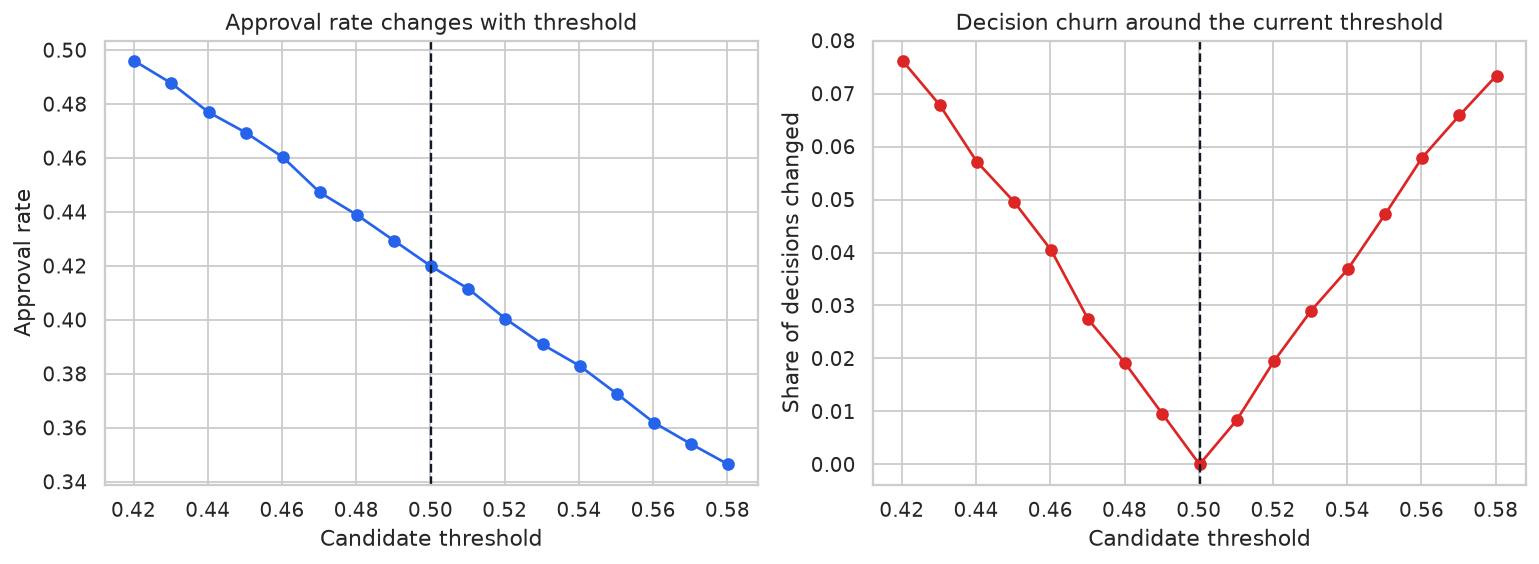

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.5))

axes[0].plot(threshold_sensitivity['candidate_threshold'], threshold_sensitivity['approval_rate'], marker='o', color='#2563eb')
axes[0].axvline(threshold, color='#111827', linestyle='--', linewidth=1.3)
axes[0].set_title('Approval rate changes with threshold')
axes[0].set_xlabel('Candidate threshold')
axes[0].set_ylabel('Approval rate')

axes[1].plot(threshold_sensitivity['candidate_threshold'], threshold_sensitivity['share_changed_vs_current'], marker='o', color='#dc2626')
axes[1].axvline(threshold, color='#111827', linestyle='--', linewidth=1.3)
axes[1].set_title('Decision churn around the current threshold')
axes[1].set_xlabel('Candidate threshold')
axes[1].set_ylabel('Share of decisions changed')

plt.tight_layout()
plt.show()

Threshold sensitivity helps explain why near-threshold cases deserve escalation. It also helps executives understand that decision volume and risk are policy choices as well as model outputs.

Use the explanation as a stress test of the model narrative. In Threshold Sensitivity for Near-Threshold Communication, the displayed reasons should make sense with the data-generating story and the operating decision. Local disagreement across methods should trigger a closer review of the case.


## 11. A Communication Quality Rubric

A good explanation packet is not judged only by whether it contains a plot. It should satisfy practical communication criteria.

In [15]:
# Section focus: 11. A Communication Quality Rubric.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

rubric = pd.DataFrame({
    'criterion': [
        'Audience fit',
        'Decision linkage',
        'Traceability',
        'Uncertainty',
        'Non-causal wording',
        'Actionability',
        'Fairness and governance',
    ],
    'question': [
        'Does the explanation match the stakeholder role and decision rights?',
        'Does it connect model evidence to the actual decision policy?',
        'Can the explanation be reproduced from model/data/version records?',
        'Does it describe score uncertainty, calibration, and threshold proximity?',
        'Does it avoid causal language unless a causal design supports it?',
        'Does it offer feasible next steps or escalation paths?',
        'Does it mention relevant fairness, monitoring, or audit caveats?',
    ],
    'packet_status': [
        'Pass',
        'Pass',
        'Needs model-card link',
        'Pass for internal users; simplify for applicant notice',
        'Pass',
        'Partial: action paths need policy review',
        'Pass for internal users; applicant notice needs approved language',
    ],
})

display_table(rubric, precision=3, max_width='940px')

,criterion,question,packet_status
0,Audience fit,Does the explanation match the stakeholder role and decision rights?,Pass
1,Decision linkage,Does it connect model evidence to the actual decision policy?,Pass
2,Traceability,Can the explanation be reproduced from model/data/version records?,Needs model-card link
3,Uncertainty,"Does it describe score uncertainty, calibration, and threshold proximity?",Pass for internal users; simplify for applicant notice
4,Non-causal wording,Does it avoid causal language unless a causal design supports it?,Pass
5,Actionability,Does it offer feasible next steps or escalation paths?,Partial: action paths need policy review
6,Fairness and governance,"Does it mention relevant fairness, monitoring, or audit caveats?",Pass for internal users; applicant notice needs approved language


In A Communication Quality Rubric, pay attention to whether the explanation changes when the analyst changes plausible settings. A setting-dependent story needs a careful qualification.


## 12. Communication Checklist

Before shipping an explanation, ask:

| Check | Why it matters |
|---|---|
| Have we stated the decision policy alongside the model score? | Decisions are made by policies using scores. |
| Have we identified the intended audience? | Different stakeholders need different levels of detail. |
| Have we avoided unsupported causal language? | Predictive explanations are not causal proof. |
| Have we explained threshold proximity? | Near-threshold cases should not be communicated as obvious. |
| Have we included uncertainty or stability information? | Point estimates can create false precision. |
| Have we documented data/model/version provenance? | Auditability requires traceability. |
| Have we checked fairness and recourse implications? | Explanations can shift burden unevenly. |
| Have we provided a review or appeal path where appropriate? | Affected stakeholders need procedural clarity. |

## 13. Key Takeaways

- Explanations are communication products as well as technical outputs.
- The same evidence base should support different stakeholder-specific summaries.
- Good communication separates score, threshold, reasons, uncertainty, limitations, and action path.
- Local feature contributions should be described as model factors, not causes.
- Near-threshold cases require special care because small policy changes can alter the decision.
- Explanation communication should be auditable: future reviewers should know what was shown, to whom, and under which model version.

## References

Lipton, Z. C. (2018). The mythos of model interpretability. *Communications of the ACM, 61*(10), 36-43. [https://doi.org/10.1145/3233231](https://doi.org/10.1145/3233231)

Miller, T. (2019). Explanation in artificial intelligence: Insights from the social sciences. *Artificial Intelligence, 267*, 1-38. [https://doi.org/10.1016/j.artint.2018.07.007](https://doi.org/10.1016/j.artint.2018.07.007)

Mitchell, M., Wu, S., Zaldivar, A., Barnes, P., Vasserman, L., Hutchinson, B., Spitzer, E., Raji, I. D., & Gebru, T. (2019). Model cards for model reporting. *Proceedings of the Conference on Fairness, Accountability, and Transparency*, 220-229. [https://doi.org/10.1145/3287560.3287596](https://doi.org/10.1145/3287560.3287596)

Ribeiro, M. T., Singh, S., & Guestrin, C. (2016). Why should I trust you? Explaining the predictions of any classifier. *Proceedings of the 22nd ACM SIGKDD International Conference on Knowledge Discovery and Data Mining*, 1135-1144. [https://doi.org/10.1145/2939672.2939778](https://doi.org/10.1145/2939672.2939778)
